# Kmeans - SAXS Segmentation

Based on https://pubmed.ncbi.nlm.nih.gov/35770824/ (**DOI**: 10.1002/jbmr.4642)

*Date: Jun 8, 2026 - By: Tomás Silva*

## 1. Imports and Configurations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 2. Load 692799 I(q) sample data
From here extract the average and standart deviation of the following features to use for the generation of the pseudo-skin data:


*   D-period
*   WP
*   Area under 3rd order curve
*   Peak width
*   Secondmoment_lu



In [2]:
file_path = 'Data/692799 IQ_fitting.csv'
df_day4 = pd.read_csv(file_path)
display(df_day4.head())

features = ['D_period', 'wp', 'area under third order curve', 'peak_width', 'secondmoment_lu']

# Initialize empty dictionaries
base_means = {}
base_stds = {}

print("--- Real Data Baselines (Day 4) ---\n")
for feature in features:
    mean_val = df_day4[feature].mean()
    std_val = df_day4[feature].std()
    
    # save on the dictionary
    base_means[feature] = mean_val
    base_stds[feature] = std_val
    
    print(f"Feature: {feature}")
    print(f"  Mean: {mean_val:.6f}")
    print(f"  Std Dev: {std_val:.6f}\n")

,x,y,total SAXS intensity,total_SAXS_norm_0_1,area under third order curve,collagen_third_norm_0_1,percentage_above_baseline,max_recorded_intensity,firstmoment,secondmoment,...,wMu,firstmoment_lu,secondmoment_lu,thirdmoment_lu,skewness_lu,D_period,peak_width,wp,peak_amplitude,fibril_radius
0,0,0,0.018897,0.004010,0.000000,1.000000e-09,34.733524,0.007163,0.281151,0.0791,...,0.187551,0.306105,0.0938,0.028730,2.599635,62.623109,0.001,0.056453,1,47.237054
1,1,0,0.019003,0.004349,0.000017,2.971487e-02,63.363078,0.005062,0.290088,0.0842,...,0.021837,0.292087,0.0853,0.024920,-0.144198,64.553274,0.001,0.006376,1,418.213630
2,2,0,0.018621,0.003124,0.000021,3.670660e-02,61.695855,0.004631,0.297568,0.0886,...,0.010000,0.282080,0.0796,0.022446,-0.662833,66.842397,0.001,0.002820,1,945.626478
3,3,0,0.019072,0.004572,0.000000,1.000000e-09,28.452648,0.006882,0.300850,0.0906,...,0.010000,0.282080,0.0796,0.022446,-0.662833,66.842397,0.001,0.002820,1,945.626478
4,4,0,0.019987,0.007506,0.000094,1.643057e-01,93.781777,0.005867,0.294687,0.0869,...,0.015918,0.297081,0.0883,0.026220,-0.503788,63.466518,0.001,0.004728,1,564.045008


--- Real Data Baselines (Day 4) ---

Feature: D_period
  Mean: 65.824251
  Std Dev: 1.510265

Feature: wp
  Mean: 0.023034
  Std Dev: 0.021533

Feature: area under third order curve
  Mean: 0.000118
  Std Dev: 0.000161

Feature: peak_width
  Mean: 0.003298
  Std Dev: 0.003104

Feature: secondmoment_lu
  Mean: 0.083125
  Std Dev: 0.003671



## 3. Generate pseudo-skin data
First, create 10 pseudo-skin samples.
* Rectangular shape (control, wounded control).
* Irregular borders (sin waves, different for each sample)
* The wounded section is divided into the upper wound and the lower wound.

For each feature
*   Control: Mean + noise
*   Upper wound: Mean + Std Dev + noise
*   Lower woud: Mean - Std Dev + noise

In [3]:
# 1. Configuration
rows, cols = 100, 200
num_samples = 10
left_boundary_base = 60
right_boundary_base = 140

# Storage lists for all 5 features
dataset_d_period = []
dataset_wp = []
dataset_area = []
dataset_peak_width = []
dataset_secondmoment = []

# 2. Build the multi-channel samples
for s in range(num_samples):

    # Initialise base grids for the Healthy Control (Mean)
    grid_dp = np.full((rows, cols), base_means['D_period'])
    grid_wp = np.full((rows, cols), base_means['wp'])
    grid_area = np.full((rows, cols), base_means['area under third order curve'])
    grid_pw = np.full((rows, cols), base_means['peak_width'])
    grid_sm = np.full((rows, cols), base_means['secondmoment_lu'])

    phase_shift = np.random.uniform(0, 5)
    wave_width = np.random.uniform(3.0, 7.0)

    for r in range(rows):
        wave_offset = np.sin((r / 8.0) + phase_shift) * wave_width
        left_bound = int(left_boundary_base + wave_offset)
        right_bound = int(right_boundary_base + wave_offset)

        # Wounded sections
        if r < 50:
            # Upper Wound (Mean + Std Dev)
            grid_dp[r, left_bound:right_bound] = base_means['D_period'] + base_stds['D_period']
            grid_wp[r, left_bound:right_bound] = base_means['wp'] + base_stds['wp']
            grid_area[r, left_bound:right_bound] = base_means['area under third order curve'] + base_stds['area under third order curve']
            grid_pw[r, left_bound:right_bound] = base_means['peak_width'] + base_stds['peak_width']
            grid_sm[r, left_bound:right_bound] = base_means['secondmoment_lu'] + base_stds['secondmoment_lu']
        else:
            # Lower Wound (Mean - Std Dev)
            grid_dp[r, left_bound:right_bound] = base_means['D_period'] - base_stds['D_period']
            grid_wp[r, left_bound:right_bound] = base_means['wp'] - base_stds['wp']
            grid_area[r, left_bound:right_bound] = base_means['area under third order curve'] - base_stds['area under third order curve']
            grid_pw[r, left_bound:right_bound] = base_means['peak_width'] - base_stds['peak_width']
            grid_sm[r, left_bound:right_bound] = base_means['secondmoment_lu'] - base_stds['secondmoment_lu']

    # Add fractional noise (Std Dev / 4)
    grid_dp += np.random.normal(0, base_stds['D_period'] / 4, (rows, cols))
    grid_wp += np.random.normal(0, base_stds['wp'] / 4, (rows, cols))
    grid_area += np.random.normal(0, base_stds['area under third order curve'] / 4, (rows, cols))
    grid_pw += np.random.normal(0, base_stds['peak_width'] / 4, (rows, cols))
    grid_sm += np.random.normal(0, base_stds['secondmoment_lu'] / 4, (rows, cols))

    # Add sample grid s in the respective list
    dataset_d_period.append(grid_dp)
    dataset_wp.append(grid_wp)
    dataset_area.append(grid_area)
    dataset_peak_width.append(grid_pw)
    dataset_secondmoment.append(grid_sm)

# 3. Convert to a 3D numpy array
final_d_period = np.array(dataset_d_period)
final_wp = np.array(dataset_wp)
final_area = np.array(dataset_area)
final_peak_width = np.array(dataset_peak_width)
final_secondmoment = np.array(dataset_secondmoment)

print("All 5 pseudo-skin datasets generated successfully!")

All 5 pseudo-skin datasets generated successfully!


### 3.1 Visualise the matrices
Plot each feature map for sample 1

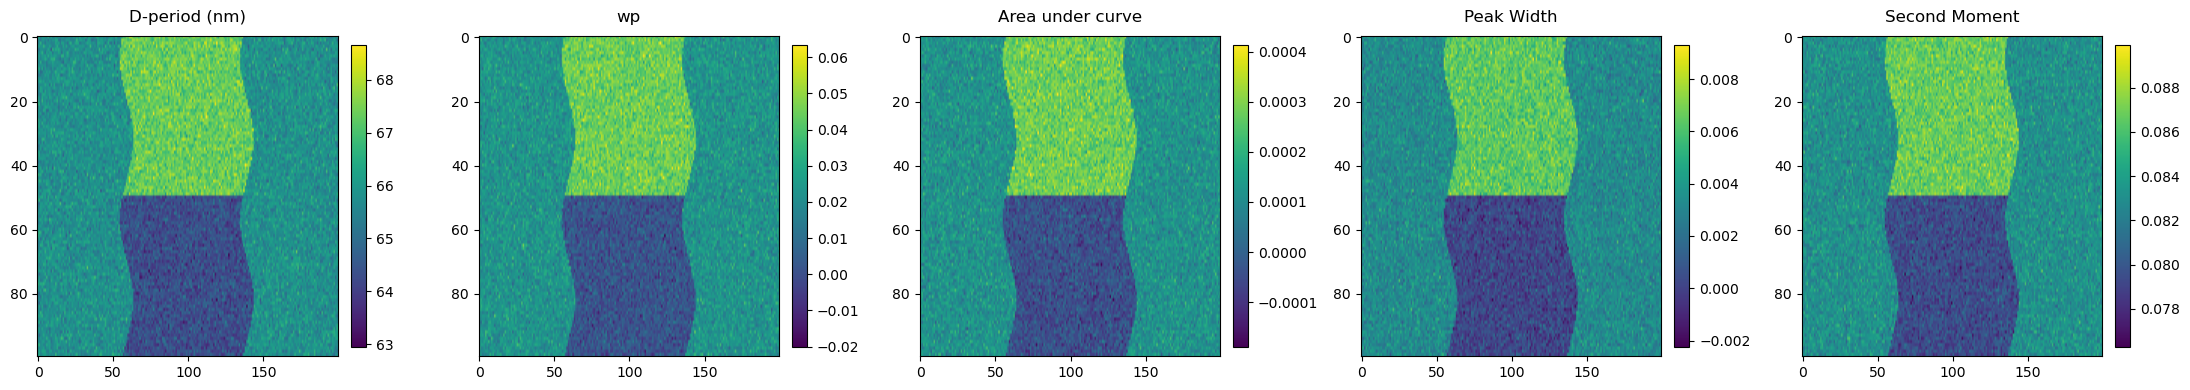

In [4]:
sample_idx = 0

sample_features = [
    final_d_period[sample_idx],
    final_wp[sample_idx],
    final_area[sample_idx],
    final_peak_width[sample_idx],
    final_secondmoment[sample_idx]
]

feature_names = [
    'D-period (nm)',
    'wp',
    'Area under curve',
    'Peak Width',
    'Second Moment'
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i in range(5):
    im = axes[i].imshow(sample_features[i], cmap='viridis', aspect='auto')
    axes[i].set_title(feature_names[i], fontsize=12, pad=10)
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04) # Add colorbar

plt.tight_layout()
plt.show()

## 4. Kmeans Model

Using 3 clusters

In [5]:
kmeans_model = KMeans(
    n_clusters=3,       # Control, Upper Wound, Lower Wound
    random_state=42,    # Forces the model to use the same random seed so your results/colours don't randomly flip every time we run
    n_init='auto'
)

print("Model built and ready to go!")

Model built and ready to go!


## 5. Run Kmeans model using 1 feature

### 5.1. D-period feature

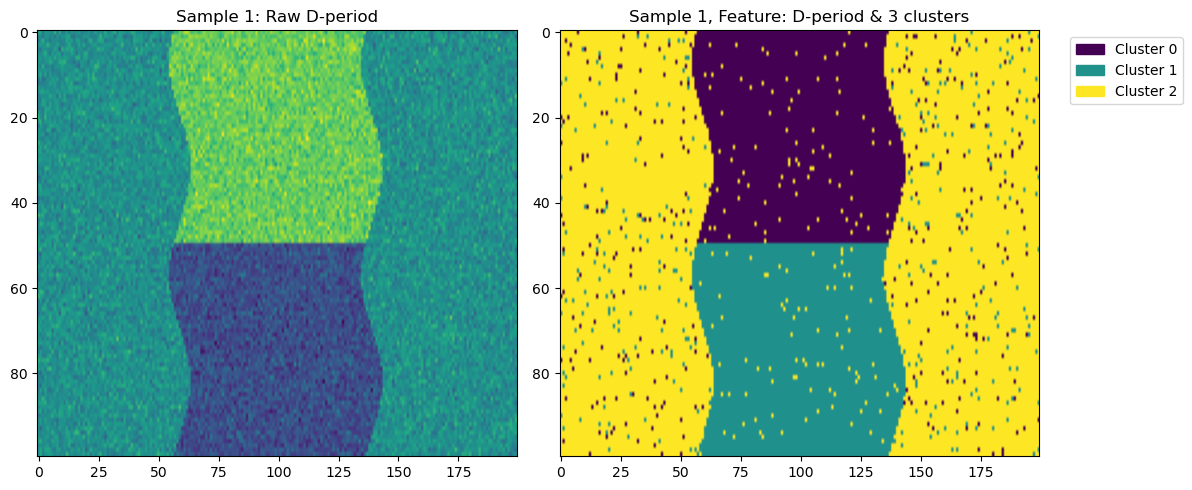

In [6]:
# Run model
sample = 0
flat_dp = final_d_period[sample].reshape(-1, 1) # Fatten data
kmeans_dp = kmeans_model.fit_predict(flat_dp) # Run Kmeans
segmented_dp = kmeans_dp.reshape(100, 200) #  Reshape the result back to the grid size (100 rows, 200 cols)

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Original Fake Data
axes[0].imshow(final_d_period[sample], cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: Raw D-period")

# Right Plot: K-means Result
im2 = axes[1].imshow(segmented_dp, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1}, Feature: D-period & 3 clusters")

colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]

# Create the label boxes
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]

# Attach the legend just outside the top right corner of the K-means plot
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5.2. WP feature

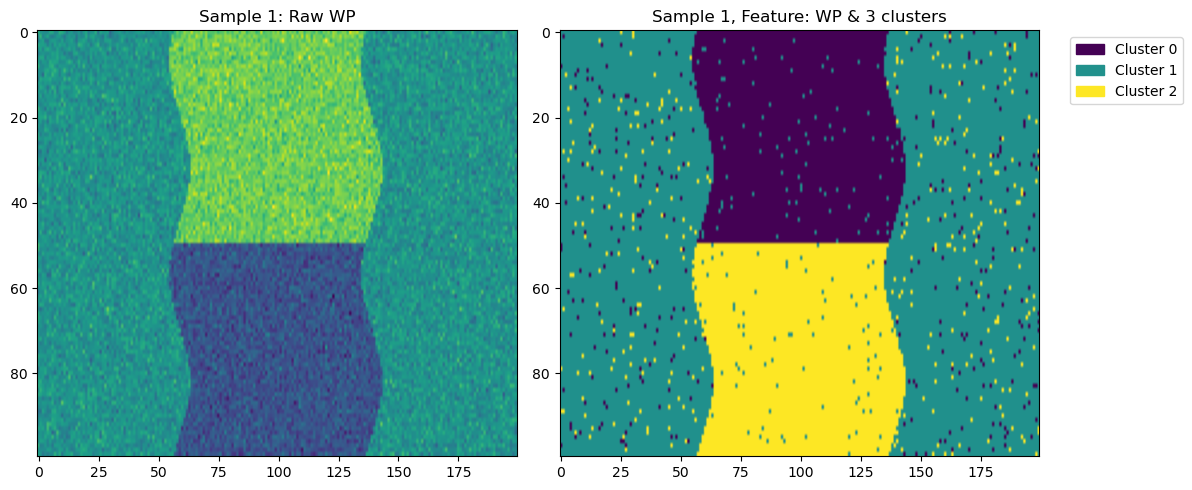

In [7]:
# Run model
sample = 0
flat_wp = final_wp[sample].reshape(-1, 1) # Fatten data
kmeans_wp = kmeans_model.fit_predict(flat_wp) # Run Kmeans
segmented_wp = kmeans_wp.reshape(100, 200) #  Reshape the result back to the grid size (100 rows, 200 cols)

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Original Fake Data
axes[0].imshow(final_wp[sample], cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: Raw WP")

# Right Plot: K-means Result
im2 = axes[1].imshow(segmented_wp, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1}, Feature: WP & 3 clusters")

colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]

# Create the label boxes
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]

# Attach the legend just outside the top right corner of the K-means plot
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5.3 Area under 3rd order curve

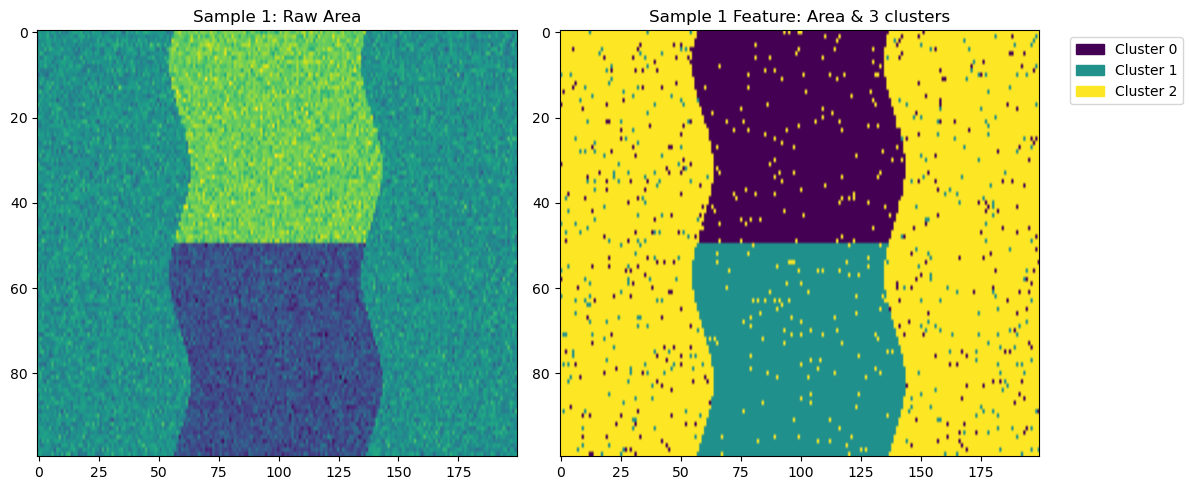

In [8]:
# Run model
sample = 0
flat_area = final_area[sample].reshape(-1, 1) # Flatten data
kmeans_area = kmeans_model.fit_predict(flat_area) # Run Kmeans
segmented_area = kmeans_area.reshape(100, 200) # Reshape the result back

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Original Fake Data
axes[0].imshow(final_area[sample], cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: Raw Area")

# Right Plot: K-means Result
im2 = axes[1].imshow(segmented_area, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1} Feature: Area & 3 clusters")

colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]

# Create the label boxes
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]

# Attach the legend just outside the top right corner of the K-means plot
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5.4 Peak Width

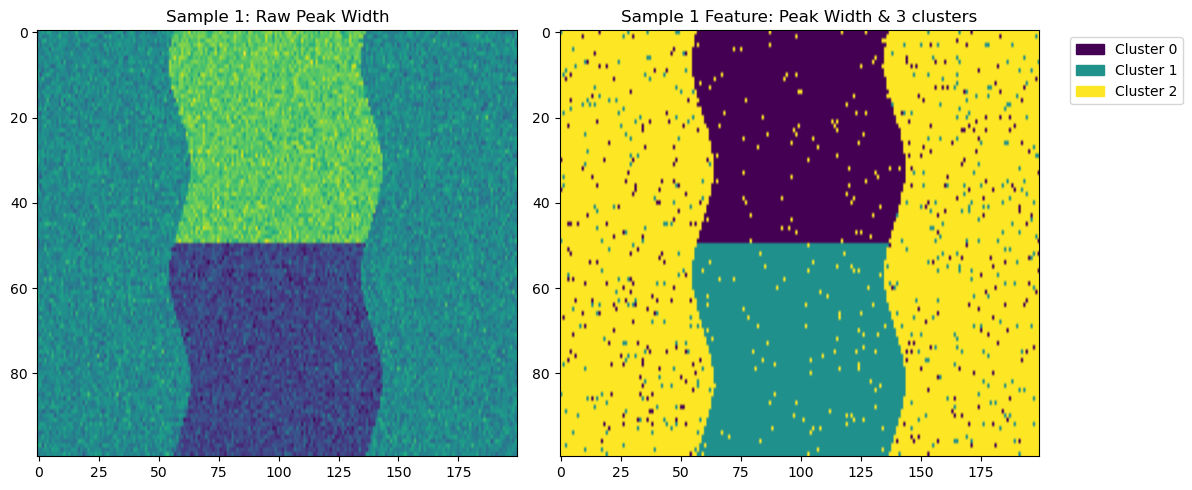

In [9]:
# Run model
sample = 0
flat_pw = final_peak_width[sample].reshape(-1, 1) # Flatten data
kmeans_pw = kmeans_model.fit_predict(flat_pw) # Run Kmeans
segmented_pw = kmeans_pw.reshape(100, 200) # Reshape the result back

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Original Fake Data
axes[0].imshow(final_peak_width[sample], cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: Raw Peak Width")

# Right Plot: K-means Result
im2 = axes[1].imshow(segmented_pw, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1} Feature: Peak Width & 3 clusters")

colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]

# Create the label boxes
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]

# Attach the legend just outside the top right corner of the K-means plot
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5.5 Second Moment

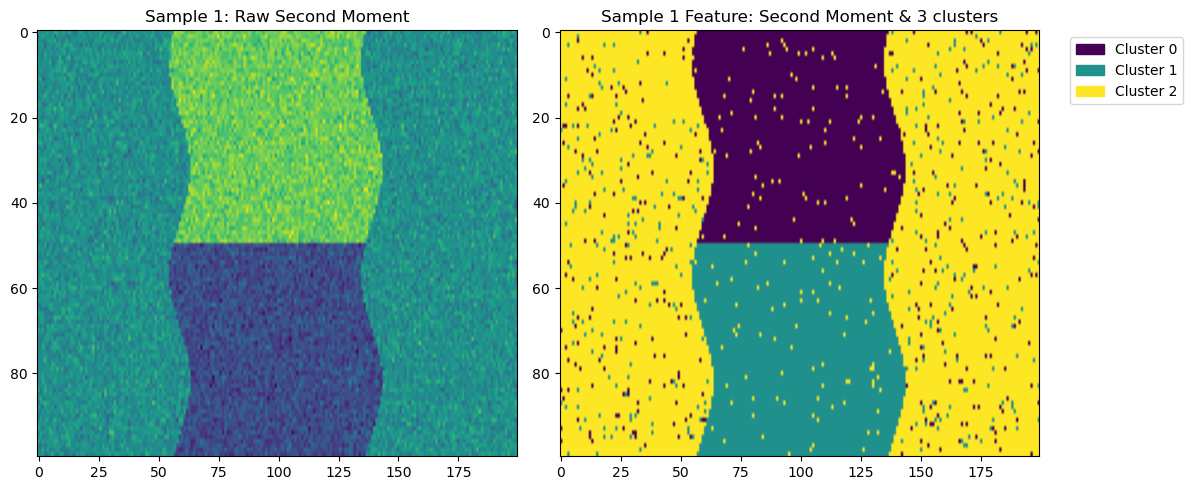

In [10]:
# Run model
sample = 0
flat_sm = final_secondmoment[sample].reshape(-1, 1) # Flatten data
kmeans_sm = kmeans_model.fit_predict(flat_sm) # Run Kmeans
segmented_sm = kmeans_sm.reshape(100, 200) # Reshape the result back

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Original Fake Data
axes[0].imshow(final_secondmoment[sample], cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: Raw Second Moment")

# Right Plot: K-means Result
im2 = axes[1].imshow(segmented_sm, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1} Feature: Second Moment & 3 clusters")

colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]

# Create the label boxes
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]

# Attach the legend just outside the top right corner of the K-means plot
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 6. Kmeans with 2 features



### 6.1. D-period & WP

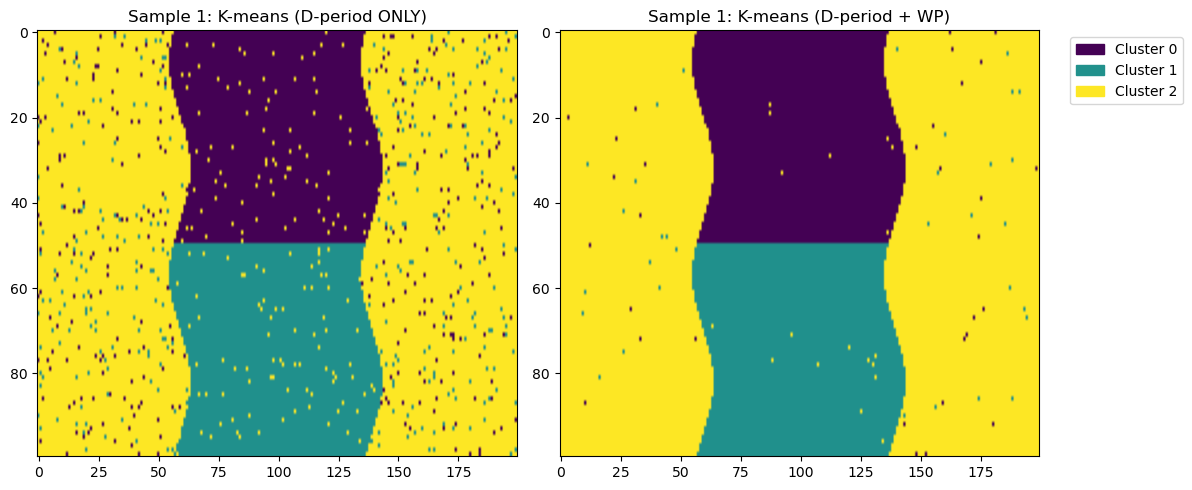

In [11]:
# 1. Setup Data
sample = 0
flat_dp = final_d_period[sample].reshape(-1, 1)
flat_wp = final_wp[sample].reshape(-1, 1)

# 2. Combine and Scale (D-period + WP)
X_combined = np.hstack((flat_dp, flat_wp))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# 3. Run K-means on Combined Data
kmeans_2d = kmeans_model.fit_predict(X_scaled)
segmented_combined = kmeans_2d.reshape(100, 200)

# 4. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: 1 Feature (Reusing your 'segmented_dp' from earlier!)
axes[0].imshow(segmented_dp, cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: K-means (D-period ONLY)")

# Right Plot: 2 Features (The New Test)
im2 = axes[1].imshow(segmented_combined, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1}: K-means (D-period + WP)")

# Legend
colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 6.2. D-period & Area under  3rd order curve

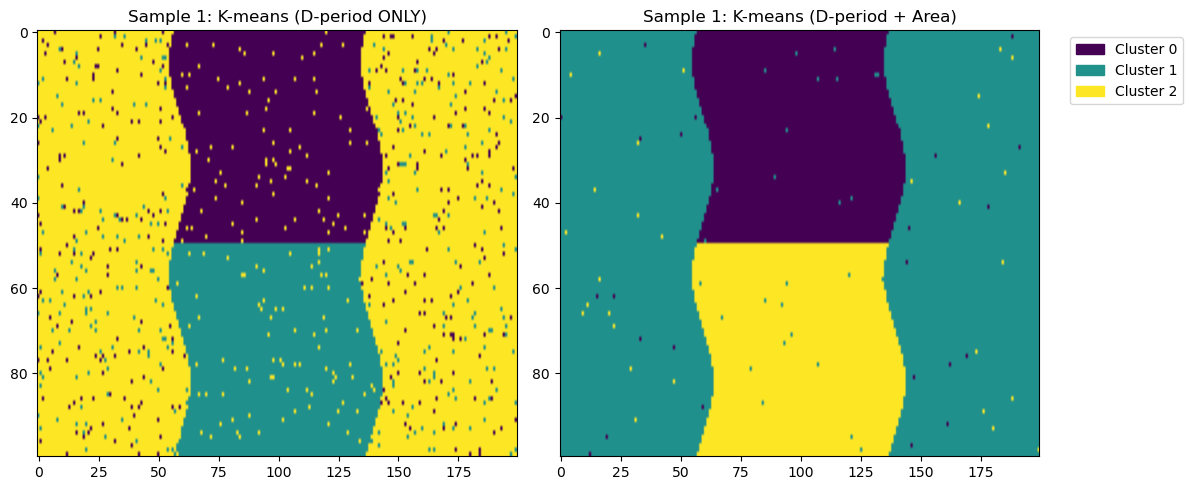

In [12]:
# 1. Setup Data
sample = 0
flat_dp = final_d_period[sample].reshape(-1, 1)
flat_area = final_area[sample].reshape(-1, 1)

# 2. Combine and Scale (D-period + Area)
X_combined = np.hstack((flat_dp, flat_area))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# 3. Run K-means on Combined Data
kmeans_2d = kmeans_model.fit_predict(X_scaled)
segmented_combined = kmeans_2d.reshape(100, 200)

# 4. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: 1 Feature (Reusing your 'segmented_dp' baseline)
axes[0].imshow(segmented_dp, cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: K-means (D-period ONLY)")

# Right Plot: 2 Features (The New Test)
im2 = axes[1].imshow(segmented_combined, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1}: K-means (D-period + Area)")

# Legend
colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 6.3 D-Period & Peak Width

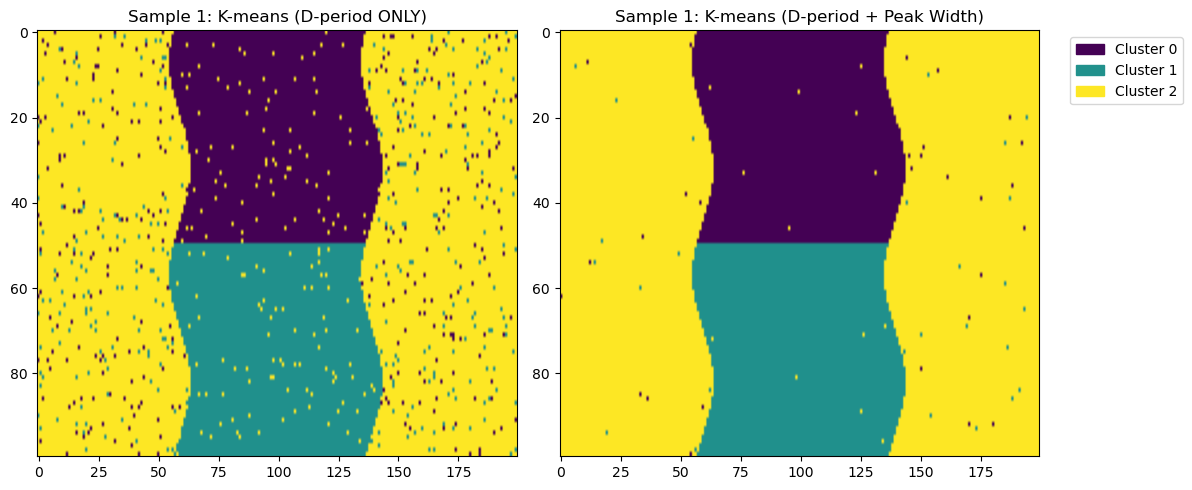

In [13]:
# 1. Setup Data
sample = 0
flat_dp = final_d_period[sample].reshape(-1, 1)
flat_pw = final_peak_width[sample].reshape(-1, 1)

# 2. Combine and Scale (D-period + Peak Width)
X_combined = np.hstack((flat_dp, flat_pw))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# 3. Run K-means on Combined Data
kmeans_2d = kmeans_model.fit_predict(X_scaled)
segmented_combined = kmeans_2d.reshape(100, 200)

# 4. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: 1 Feature (Reusing your 'segmented_dp' baseline)
axes[0].imshow(segmented_dp, cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: K-means (D-period ONLY)")

# Right Plot: 2 Features (The New Test)
im2 = axes[1].imshow(segmented_combined, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1}: K-means (D-period + Peak Width)")

# Legend
colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 7. Kmeans with 3 features

### 7.1 D-period, Area under curve & WP

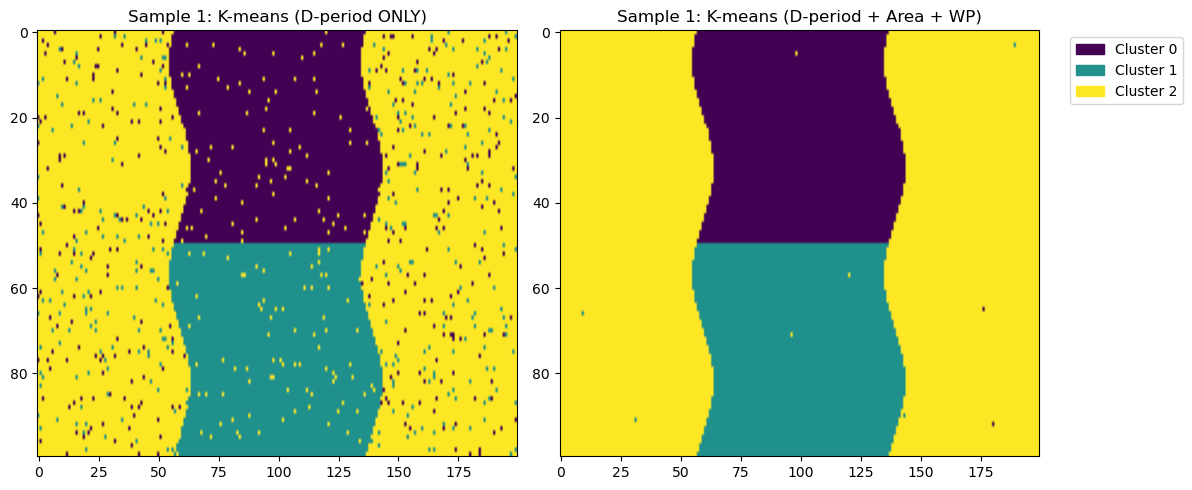

In [14]:
# 1. Set up data for all 3 features
sample = 0
flat_dp = final_d_period[sample].reshape(-1, 1)
flat_area = final_area[sample].reshape(-1, 1)
flat_wp = final_wp[sample].reshape(-1, 1)

# 2. Combine and Scale (D-period + Area + WP)
X_combined = np.hstack((flat_dp, flat_area, flat_wp))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# 3. Run K-means on the 3D Combined Data
kmeans_3d = kmeans_model.fit_predict(X_scaled)
segmented_combined_3d = kmeans_3d.reshape(100, 200)

# 4. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: 1 Feature (Reusing your 'segmented_dp' baseline)
axes[0].imshow(segmented_dp, cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: K-means (D-period ONLY)")

# Right Plot: 3 Features (The New Test)
im2 = axes[1].imshow(segmented_combined_3d, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1}: K-means (D-period + Area + WP)")

# Legend
colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 8. Kmeans with 4 features

### 8.1 D-period, Area under curve, WP & peak width

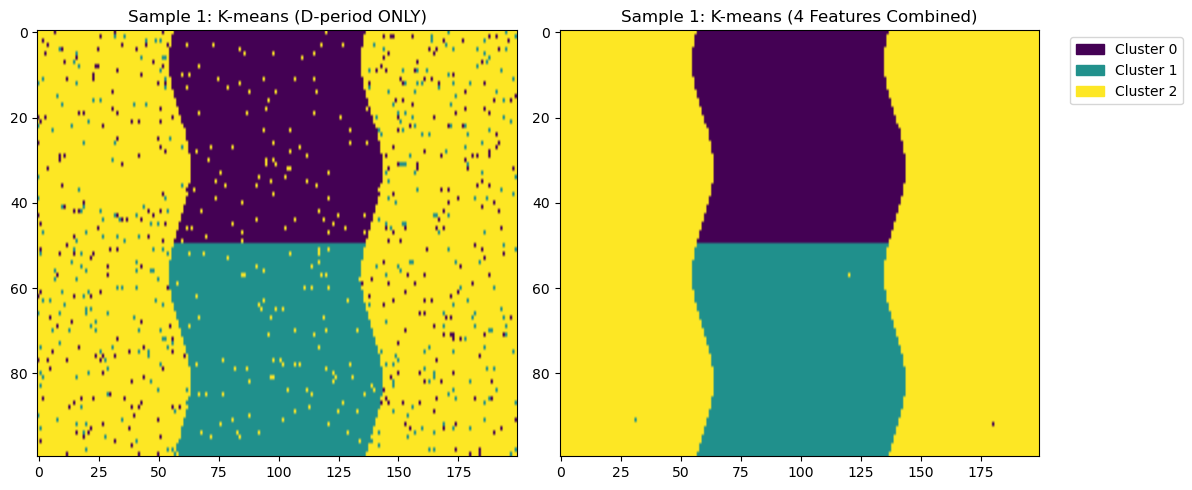

In [15]:
# 1. Setup Data for all 4 features
sample = 0
flat_dp = final_d_period[sample].reshape(-1, 1)
flat_area = final_area[sample].reshape(-1, 1)
flat_wp = final_wp[sample].reshape(-1, 1)
flat_pw = final_peak_width[sample].reshape(-1, 1)

# 2. Combine and Scale (D-period + Area + WP + Peak Width)
X_combined = np.hstack((flat_dp, flat_area, flat_wp, flat_pw))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# 3. Run K-means on the 4D Combined Data
kmeans_4d = kmeans_model.fit_predict(X_scaled)
segmented_combined_4d = kmeans_4d.reshape(100, 200)

# 4. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: 1 Feature (Reusing your 'segmented_dp' baseline)
axes[0].imshow(segmented_dp, cmap='viridis', aspect='auto')
axes[0].set_title(f"Sample {sample + 1}: K-means (D-period ONLY)")

# Right Plot: 4 Features (The New Test)
im2 = axes[1].imshow(segmented_combined_4d, cmap='viridis', aspect='auto')
axes[1].set_title(f"Sample {sample + 1}: K-means (4 Features Combined)")

# Legend
colors = [im2.cmap(im2.norm(val)) for val in [0, 1, 2]]
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Combined

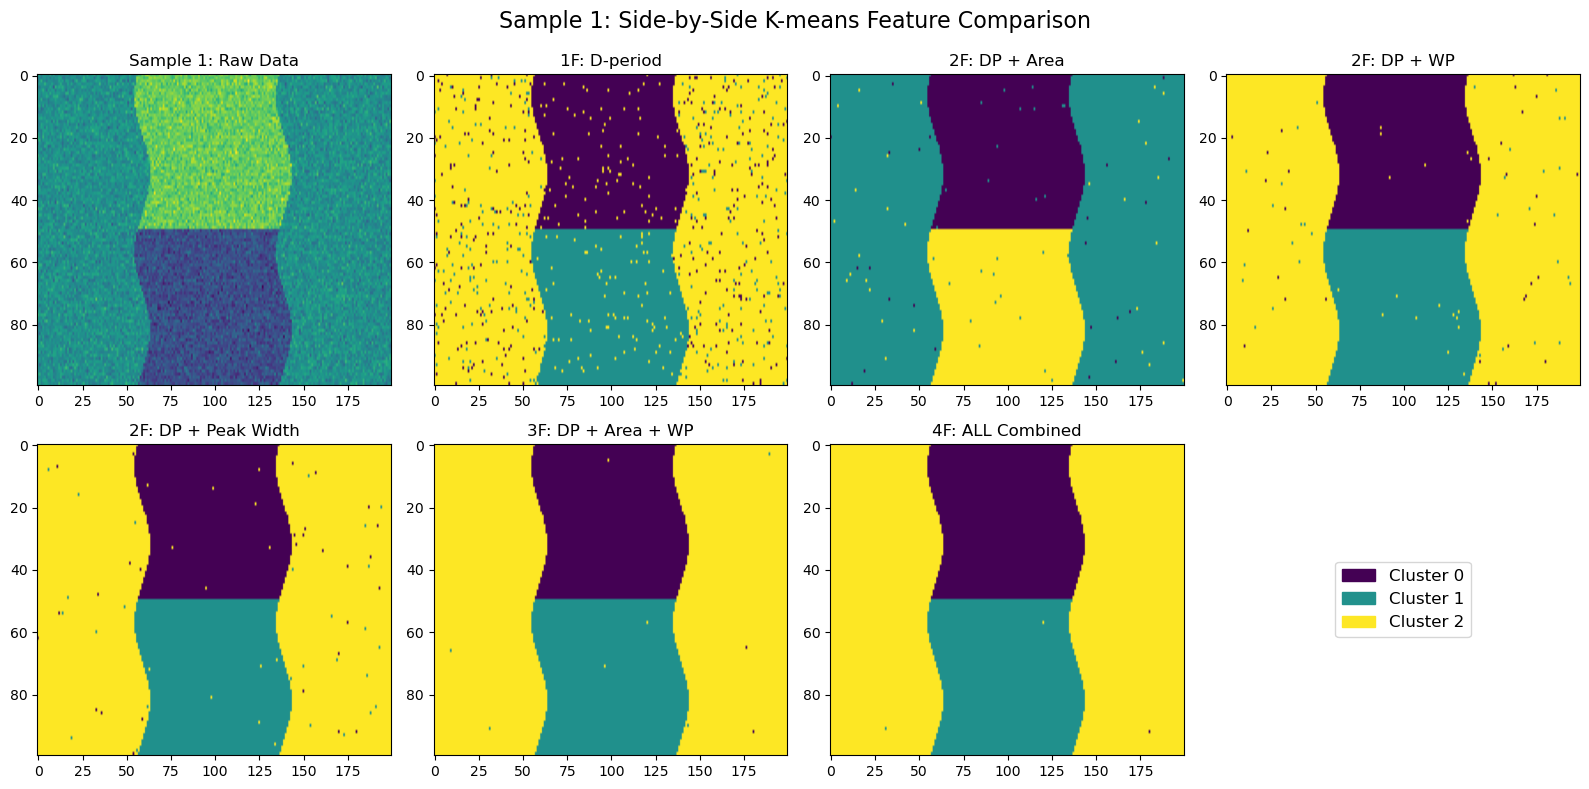

In [16]:
# --- SETUP & INITIALIZATION ---
sample = 0
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init='auto') # Define the model once
scaler = StandardScaler()

# Flatten all features for this sample
flat_dp = final_d_period[sample].reshape(-1, 1)
flat_area = final_area[sample].reshape(-1, 1)
flat_wp = final_wp[sample].reshape(-1, 1)
flat_pw = final_peak_width[sample].reshape(-1, 1)


# --- 1. RUN: 1 FEATURE (D-PERIOD) ---
labels_1d = kmeans_model.fit_predict(flat_dp)
segmented_1d = labels_1d.reshape(100, 200) # SAVED in segmented_1d


# --- 2. RUN: 2 FEATURES (D-PERIOD + WP) ---
# Combine, Scale, and Run
X_combined_2d_wp = np.hstack((flat_dp, flat_wp))
X_scaled_2d_wp = scaler.fit_transform(X_combined_2d_wp)
labels_2d_wp = kmeans_model.fit_predict(X_scaled_2d_wp)
segmented_2d_wp = labels_2d_wp.reshape(100, 200) # SAVED in segmented_2d_wp


# --- 3. RUN: 2 FEATURES (D-PERIOD + AREA) ---
# Combine, Scale, and Run
X_combined_2d_area = np.hstack((flat_dp, flat_area))
X_scaled_2d_area = scaler.fit_transform(X_combined_2d_area)
labels_2d_area = kmeans_model.fit_predict(X_scaled_2d_area)
segmented_2d_area = labels_2d_area.reshape(100, 200) # SAVED in segmented_2d_area


# --- 4. RUN: 2 FEATURES (D-PERIOD + PEAK WIDTH) ---
# Combine, Scale, and Run
X_combined_2d_pw = np.hstack((flat_dp, flat_pw))
X_scaled_2d_pw = scaler.fit_transform(X_combined_2d_pw)
labels_2d_pw = kmeans_model.fit_predict(X_scaled_2d_pw)
segmented_2d_pw = labels_2d_pw.reshape(100, 200) # SAVED in segmented_2d_pw


# --- 5. RUN: 3 FEATURES (D-PERIOD + AREA + WP) ---
# Combine, Scale, and Run
X_combined_3d = np.hstack((flat_dp, flat_area, flat_wp))
X_scaled_3d = scaler.fit_transform(X_combined_3d)
labels_3d = kmeans_model.fit_predict(X_scaled_3d)
segmented_3d = labels_3d.reshape(100, 200) # SAVED in segmented_3d


# --- 6. RUN: 4 FEATURES (D-PERIOD + AREA + WP + PEAK WIDTH) ---
# Combine, Scale, and Run
X_combined_4d = np.hstack((flat_dp, flat_area, flat_wp, flat_pw))
X_scaled_4d = scaler.fit_transform(X_combined_4d)
labels_4d = kmeans_model.fit_predict(X_scaled_4d)
segmented_4d = labels_4d.reshape(100, 200) # SAVED in segmented_4d


# ==============================================================================
# --- PLOT ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 1. Original Fake Data (as a baseline)
axes[0, 0].imshow(final_d_period[sample], cmap='viridis', aspect='auto')
axes[0, 0].set_title(f"Sample {sample+1}: Raw Data")

# 2. 1 Feature (D-Period)
axes[0, 1].imshow(segmented_1d, cmap='viridis', aspect='auto')
axes[0, 1].set_title("1F: D-period")

# 3. 2 Features (+ Area)
axes[0, 2].imshow(segmented_2d_area, cmap='viridis', aspect='auto')
axes[0, 2].set_title("2F: DP + Area")

# 4. 2 Features (+ WP)
axes[0, 3].imshow(segmented_2d_wp, cmap='viridis', aspect='auto')
axes[0, 3].set_title("2F: DP + WP")

# 5. 2 Features (+ Peak Width)
axes[1, 0].imshow(segmented_2d_pw, cmap='viridis', aspect='auto')
axes[1, 0].set_title("2F: DP + Peak Width")

# 6. 3 Features (Dperiod + Area + WP)
axes[1, 1].imshow(segmented_3d, cmap='viridis', aspect='auto')
axes[1, 1].set_title("3F: DP + Area + WP")

# 7. 4 Features (Dperiod + Area + WP + Peak Width)
im7 = axes[1, 2].imshow(segmented_4d, cmap='viridis', aspect='auto') # im7 to generate the legend later
axes[1, 2].set_title("4F: ALL Combined")

# 8. Empty placeholder for the legend
axes[1, 3].axis('off') # Hide the axes of this empty subplot

# --- CREATE THE LEGEND ON THE BOTTOM RIGHT PLOT ---
colors = [im7.cmap(im7.norm(val)) for val in [0, 1, 2]]
patches = [
    mpatches.Patch(color=colors[0], label='Cluster 0'),
    mpatches.Patch(color=colors[1], label='Cluster 1'),
    mpatches.Patch(color=colors[2], label='Cluster 2')
]
# Attach the legend to the empty axes[1, 3] plot area
axes[1, 3].legend(handles=patches, loc='center', fontsize=12)

# Global labels and layout
fig.suptitle(f"Sample {sample+1}: Side-by-Side K-means Feature Comparison", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90) # Make room for the super title
plt.show()